# Service Alert Delay Correlation

Compares observed delays during active service alerts with observations without active alerts.

In [1]:
from pathlib import Path
import importlib.util
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "analysis"))

spec = importlib.util.spec_from_file_location(
    "service_alert_delay_correlation",
    PROJECT_ROOT / "analysis" / "service-alert-delay-correlation.py",
)
service_alerts = importlib.util.module_from_spec(spec)
spec.loader.exec_module(service_alerts)

DB = PROJECT_ROOT / "data" / "foli.db"
GTFS_DIR = None
LIMIT = 20
MIN_OBSERVATIONS = 100
ALERT_KIND = "route"  # "route", "stop", or "any"
LINE_REF = None

Route alert matching is the default because it is much faster on the current data. Stop-level alert matching can be enabled with `ALERT_KIND = "stop"`.

In [2]:
class Args:
    db = DB
    gtfs_dir = GTFS_DIR
    limit = LIMIT
    min_observations = MIN_OBSERVATIONS
    alert_kind = ALERT_KIND
    line_ref = LINE_REF

overall, line = service_alerts.build_correlation(Args)
overall

,obs_count_no_alert,obs_count_alert,avg_delay_min_no_alert,avg_delay_min_alert,delay_lift_min,pct_late_no_alert,pct_late_alert,late_pct_point_lift,pct_over_3_min_late_no_alert,pct_over_3_min_late_alert,over_3_min_late_pct_point_lift,pct_route_alert_alert,pct_stop_alert_alert
0,713999,556017,-0.03,-0.02,0.01,38.08,42.85,4.77,9.12,8.85,-0.27,100.0,0.0


In [3]:
line

,line_ref,line_name,obs_count_no_alert,obs_count_alert,avg_delay_min_no_alert,avg_delay_min_alert,delay_lift_min,pct_late_no_alert,pct_late_alert,late_pct_point_lift,pct_over_3_min_late_no_alert,pct_over_3_min_late_alert,over_3_min_late_pct_point_lift,pct_route_alert_alert,pct_stop_alert_alert
3,21,21,14583,633,1.86,3.18,1.32,53.47,80.09,26.63,27.54,45.02,17.48,100.0,0.0
5,600,600,6782,5334,-1.45,-1.03,0.42,30.23,21.24,-8.99,4.22,1.67,-2.55,100.0,0.0
1,10A,10A,60419,3642,-0.46,-0.62,-0.16,31.81,24.66,-7.15,5.01,1.46,-3.55,100.0,0.0
2,20,20,9475,6677,-0.23,-0.71,-0.48,43.00,29.83,-13.16,2.84,1.86,-0.98,100.0,0.0
4,3,3,20929,67011,0.10,-0.46,-0.56,42.26,41.22,-1.03,8.88,6.98,-1.90,100.0,0.0
6,601,601,6595,5487,-0.46,-1.07,-0.61,27.40,18.44,-8.96,2.56,1.84,-0.72,100.0,0.0
0,10,10,38338,19404,0.24,-1.15,-1.39,33.62,21.85,-11.77,5.79,1.88,-3.91,100.0,0.0


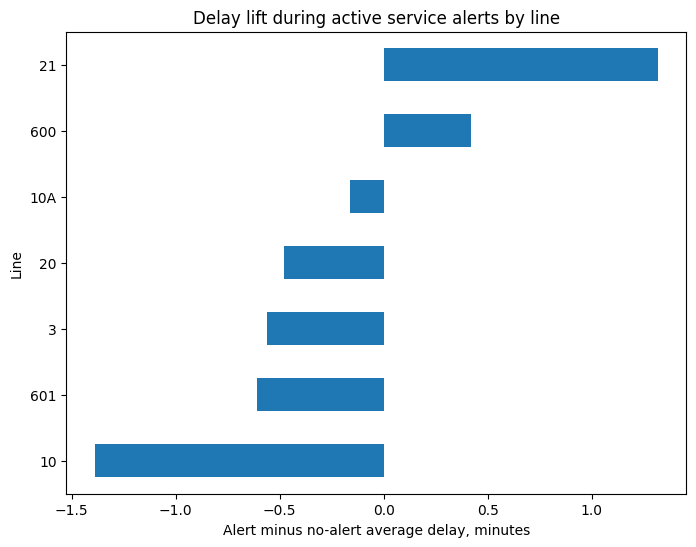

In [4]:
if not line.empty:
    ax = line.sort_values("delay_lift_min").plot.barh(
        x="line_ref",
        y="delay_lift_min",
        legend=False,
        figsize=(8, 6),
        title="Delay lift during active service alerts by line",
    )
    ax.set_xlabel("Alert minus no-alert average delay, minutes")
    ax.set_ylabel("Line")